# NMF with TF-IDF
* Vectorization with TF-IDF
* NMF for topic modeling
* Model evaluation with reconstruction error, coherence, and topic diversity
* Visualization with PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, PCA
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import umap
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid', context='paper')

In [2]:
# Load preprocessed data
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big_bang]",time define big_bang
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific_explanation, atmospheri...",ufo good scientific_explanation atmospherical ...
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",(),"[s, commonly, know, fact, metal, oxidize, poss...",s commonly know fact metal oxidize possible di...
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research_project, shor...",geoscientist current research_project shortfal...


## TF-IDF Vectorization

In [3]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1),
    min_df=5,            # ignore words in < 5 docs
    max_df=0.8           # ignore words in > 80% of docs
)
X = vectorizer.fit_transform(df['clean_text'])

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(vectorizer.get_feature_names_out())
# Sparse feature matrix
print(X)

10000
['00' '00_00' '00_year' ... 'zoology' 'zoom' 'zygote']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3619007 stored elements and shape (591178, 10000)>
  Coords	Values
  (0, 9134)	0.38975418127933237
  (0, 2482)	0.6861664120449172
  (0, 1080)	0.6142209155968902
  (1, 9367)	0.5503332389657914
  (1, 4086)	0.30062202907411234
  (1, 7909)	0.46737197556934584
  (1, 3277)	0.3811243249822899
  (1, 5745)	0.49301866808872985
  (2, 1924)	0.4664460421950509
  (2, 5128)	0.24619228562412446
  (2, 3454)	0.3836851142824323
  (2, 5735)	0.3613525524970021
  (2, 6482)	0.5251513872321245
  (2, 6945)	0.22711939482781837
  (2, 3931)	0.34155572763890385
  (3, 1701)	0.5610085523196993
  (3, 1368)	0.42508145152853666
  (3, 5171)	0.37784760111484705
  (3, 8982)	0.49374017115323093
  (3, 7284)	0.3435505748967413
  (4, 2336)	0.314455135342072
  (4, 7619)	0.5137052202804001
  (4, 5092)	0.4211874428828948
  (4, 5820)	0.42256588615769203
  (4, 3069)	0.3277825986608701
  :	:
  (591173, 7284)	0.

## Hyperparameter Tuning
### Finding the best values for k

In [4]:
dictionary = Dictionary(df['post_tokens'])

In [5]:
# Model evaluation
def evaluate_model(nmf, vectorizer, texts, dictionary, top_n=10):

    # Reconstruction error
    errors = nmf.reconstruction_err_

    # Extract topics
    feature_names = np.array(vectorizer.get_feature_names_out())

    topics = []

    for topic in nmf.components_:
        top_words = feature_names[topic.argsort()[-top_n:]]
        topics.append(list(top_words))

    # Coherence
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = cm.get_coherence()

    # Topic diversity
    all_topic_words = []

    for topic in topics:
        all_topic_words.extend(topic)

    diversity = len(set(all_topic_words)) / len(all_topic_words)

    return coherence, errors, diversity

In [6]:
# Plotting evaluation metrics
def plot_nmf_metrics(results, k_min, k_max, step):

    # Extract values from results
    k_vals = [r[0] for r in results]
    coherence = np.array([r[1] for r in results]).reshape(-1, 1)
    errors = np.array([r[2] for r in results]).reshape(-1, 1)
    diversity = np.array([r[3] for r in results]).reshape(-1, 1)

    # Build summary table
    summary = pd.DataFrame({
        'k': k_vals,
        'Coherence': coherence.flatten(),
        'Diversity': diversity.flatten(),
        'Reconstruction_Error': errors.flatten()
    })

    # Normalize metrics
    scaler = MinMaxScaler()
    summary[['Coherence_norm', 'Diversity_norm', 'Error_norm']] = scaler.fit_transform(
        summary[['Coherence', 'Diversity', 'Reconstruction_Error']]
    )

    # Invert reconstruction error
    summary['Error_norm'] = 1 - summary['Error_norm']

    # Plot
    plt.figure(figsize=(10, 6))

    # Plot metrics
    plt.plot(k_vals, summary['Coherence_norm'], marker='o', label='Coherence')
    plt.plot(k_vals, summary['Error_norm'], marker='s', label='Reconstruction Error (inverted)')
    plt.plot(k_vals, summary['Diversity_norm'], marker='^', label='Topic Diversity')
    
    # Labels and title
    plt.xlabel("Number of Topics (k)")
    plt.ylabel("Normalized Score")
    plt.title("NMF Model Evaluation")

    # Legend and grid
    plt.legend()
    plt.grid(visible=True)
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(5))

    # Despine
    for spine in ['top', 'right', 'bottom', 'left']:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()

    # Save viz
    plt.savefig(f'viz/NMF_evaluation_metrics-{k_min}-{k_max}-{step}.png', dpi=300)
    plt.show()

    # Print table with evaluation scores
    print(summary[['k', 'Coherence', 'Diversity', 'Reconstruction_Error', 'Coherence_norm', 'Diversity_norm', 'Error_norm']])

### NMF Loop for different values of *k*

Running NMF for k=2
Running NMF for k=3
Running NMF for k=4
Running NMF for k=5
Running NMF for k=6
Running NMF for k=7
Running NMF for k=8
Running NMF for k=9
Running NMF for k=10
Running NMF for k=11
Running NMF for k=12
Running NMF for k=13
Running NMF for k=14
Running NMF for k=15
Running NMF for k=16
Running NMF for k=17
Running NMF for k=18
Running NMF for k=19
Running NMF for k=20
Running NMF for k=21
Running NMF for k=22
Running NMF for k=23
Running NMF for k=24
Running NMF for k=25
Running NMF for k=26
Running NMF for k=27
Running NMF for k=28
Running NMF for k=29
Running NMF for k=30
Running NMF for k=31
Running NMF for k=32
Running NMF for k=33
Running NMF for k=34
Running NMF for k=35
Running NMF for k=36
Running NMF for k=37
Running NMF for k=38
Running NMF for k=39
Running NMF for k=40
Running NMF for k=41
Running NMF for k=42
Running NMF for k=43
Running NMF for k=44
Running NMF for k=45
Running NMF for k=46
Running NMF for k=47
Running NMF for k=48
Running NMF for k=49


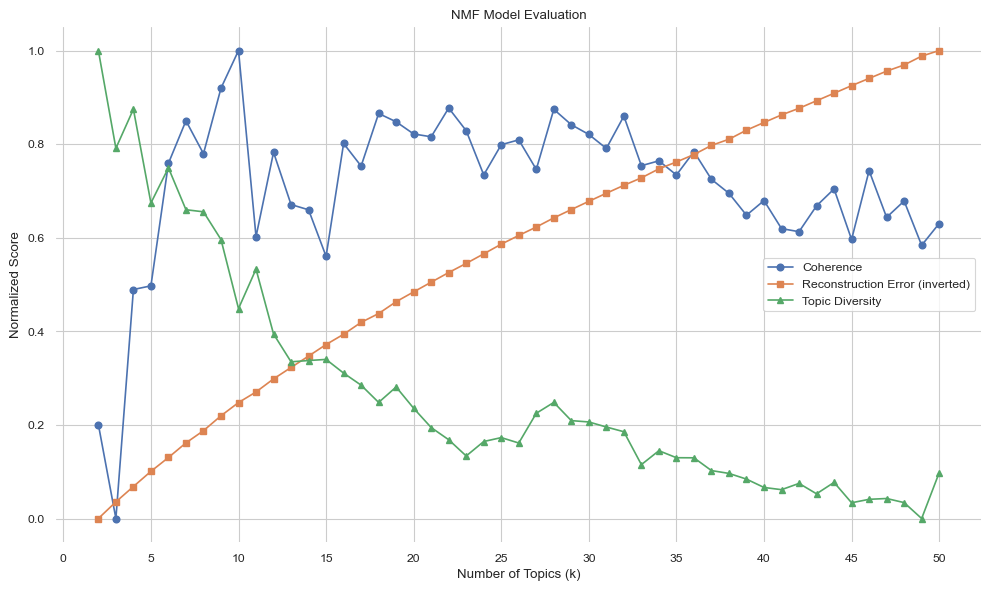

     k  Coherence  Diversity  Reconstruction_Error  Coherence_norm  \
0    2   0.549732   0.950000            762.982261        0.200865   
1    3   0.530532   0.866667            761.552660        0.000000   
2    4   0.577308   0.900000            760.236826        0.489358   
3    5   0.578054   0.820000            758.934185        0.497165   
4    6   0.603089   0.850000            757.744550        0.759078   
5    7   0.611773   0.814286            756.490618        0.849924   
6    8   0.605046   0.812500            755.443481        0.779551   
7    9   0.618430   0.788889            754.164512        0.919571   
8   10   0.626118   0.730000            753.028517        1.000000   
9   11   0.588106   0.763636            752.118600        0.602331   
10  12   0.605330   0.708333            750.997139        0.782525   
11  13   0.594661   0.684615            750.016385        0.670906   
12  14   0.593588   0.685714            749.038803        0.659682   
13  15   0.584084   

In [7]:
k_min = 2
k_max = 50
step = 1
k_values = range(k_min, k_max + 1, step)

results = []

for k in k_values:
    print(f"Running NMF for k={k}")

    # Fit NMF model
    nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
    W = nmf.fit_transform(X)
    H = nmf.components_

    # Get evaluation metrics
    coherence, error, diversity = evaluate_model(
    nmf, vectorizer, df['post_tokens'], dictionary
    )

    results.append((k, coherence, error, diversity))

plot_nmf_metrics(results, k_min=k_min, k_max=k_max, step=step)

The coherence score is the most important model evaluation metric. Is shows a spike at *k = 10*. The inverted reconstruction error shows a monotonically increasing curve and thus does not hint towards a specific value of k. Topic diversity decreases with increasing *k*, showing that a smaller number is more suitable. The best value for *k* is *k = 10*. It has the highest coherence score with medium high topic diversity.

## Final Runs with Best Values for *k*

In [8]:
def get_topic_labels(model, vectorizer, n_words=5):
    """Generate formatted labels for each topic based on the top words for each topic."""
    
    words = vectorizer.get_feature_names_out()
    topic_labels = {}

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
    
        topic_labels[i] = f"Topic {i}: " + " | ".join(top_words)

    return topic_labels

In [9]:
def get_top_words(model, vectorizer, n_top=15):
    """Return top words for each topic as list of lists."""

    feature_names = vectorizer.get_feature_names_out()
    topics = []
    
    for comp in model.components_:
        top_idx = np.argsort(comp)[::-1][:n_top]
        topics.append([feature_names[i] for i in top_idx])
    
    return topics

In [10]:
def plot_bars_topic_distribution(k):
    """
    Create a bar plot showing the distribution of documents across topics, with topic labels based on top words.
    """

    # Set color
    color = plt.colormaps["tab20b"](0)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.countplot(
        data=df,
        y=f"topic_label_k{k}",
        order=df[f'topic_label_k{k}'].value_counts().index,
        ax=ax,
        color=color
    )

    # Formatting
    ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)

    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # Despine
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="y", visible=False)

    plt.tight_layout()

    # Save and show
    plt.savefig(f"viz/NMF_posts_per_topic_k{k}.png", dpi=300)
    plt.show()

In [11]:
def plot_box_topic_confidence(k):
    """
    Plot boxplot of topic probabilities with top words as legend.
    """

    # Set color
    color = plt.colormaps["tab20b"](5)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x=f"topic_k{k}",
        y=f"topic_prob_k{k}",
        color=color,
        ax=ax
    )

    # Titles and labels
    ax.set_title("Topic Confidence Distribution per Topic", fontsize=16)
    ax.set_xlabel("Topic", fontsize=12)
    ax.set_ylabel("Topic Confidence", fontsize=12)

    # Despine
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    
    # Save and show
    plt.savefig(f"viz/NMF_topic_confidence_k{k}.png", dpi=300)
    plt.show()

In [ ]:
def plot_pca_projection(W, k, df):

    topic_ids = sorted(df[f"topic_k{k}"].unique())
    cmap = plt.colormaps.get_cmap("tab20")

    color_map = {
        t: cmap(i % 20)
        for i, t in enumerate(topic_ids)
    }

    topic_colors = df[f"topic_k{k}"].map(color_map)
    spine_color = '#cccccc'

    pca = PCA(n_components=2, random_state=42)
    W_pca = pca.fit_transform(W)

    plt.figure(figsize=(10,6))

    plt.scatter(
        W_pca[:,0],
        W_pca[:,1],
        c=topic_colors,
        s=1,
        alpha=0.25,
        rasterized=True
    )

    plt.title(f"PCA Projection of NMF Topic Space (k={k})", fontsize=16)
    plt.xlabel("PC1", fontsize=12)
    plt.ylabel("PC2", fontsize=12)
    plt.grid(alpha=0.3)

    legend_elements = [
        Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(t % 20),
            markersize=8,
            label=f"Topic {t}"
        )
        for t in topic_ids
    ]

    plt.legend(
        handles=legend_elements,
        title="Topics",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False,
        fontsize=10
    )

    for spine in plt.gca().spines.values():
            spine.set_color(spine_color)

    plt.tight_layout()
    plt.savefig(f"viz/NMF_PCA_k{k}.png", dpi=300)
    plt.show()

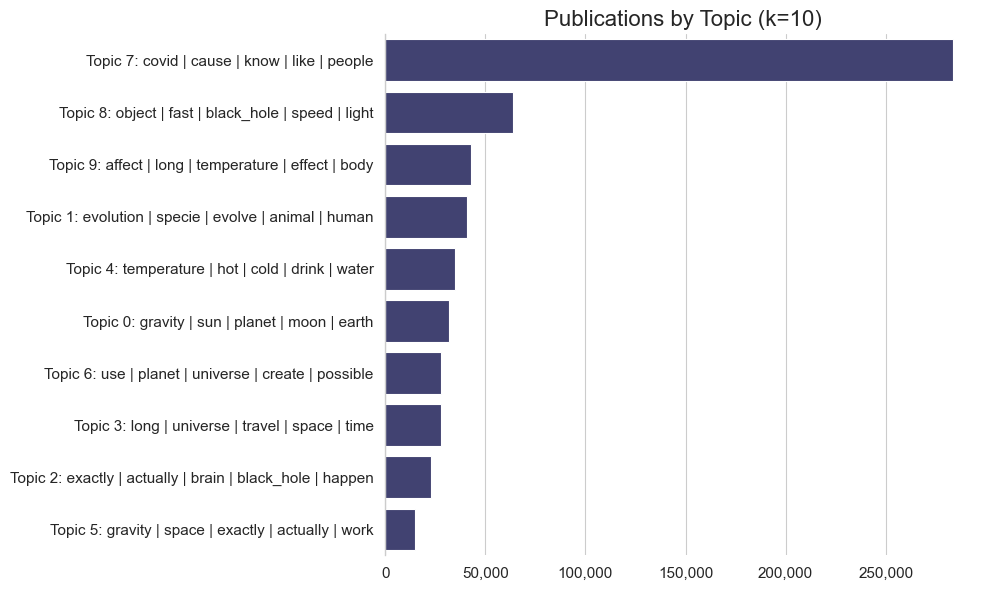

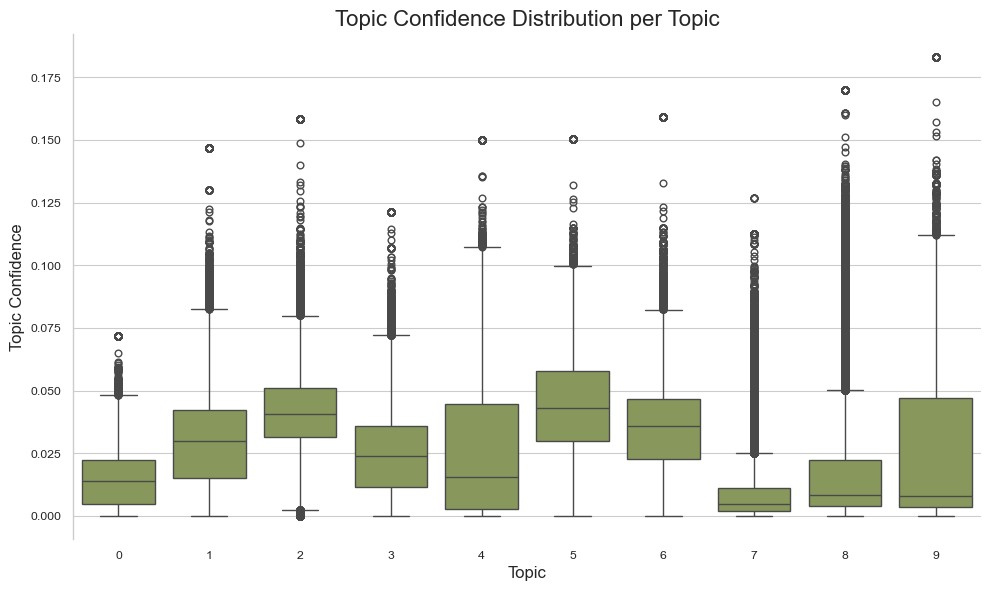

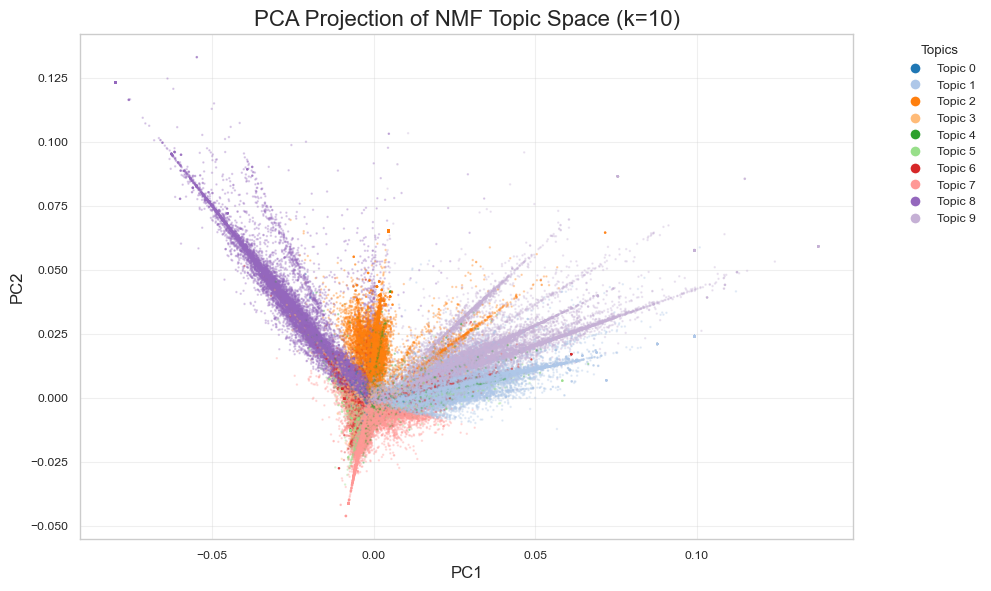

In [13]:
k = 10

nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
W = nmf.fit_transform(X)

# Assign topics to documents and add to df
df[f"topic_k{k}"] = W.argmax(axis=1)
df[f"topic_prob_k{k}"] = W.max(axis=1)

topic_labels = get_topic_labels(nmf, vectorizer)
df[f'topic_label_k{k}'] = df[f"topic_k{k}"].map(topic_labels)

# Get and save top words
top_words = get_top_words(nmf, vectorizer, n_top=15)
top_words_df = pd.DataFrame({
    f"Topic {i}": words for i, words in enumerate(top_words)
})
top_words_df.to_csv(f"topics/NMF_top_words_k{k}.csv", index=False)

# Plot topic distribution
plot_bars_topic_distribution(k=k)

# Plot topic confidence
plot_box_topic_confidence(k=k)

# PCA projection into 2D space
plot_pca_projection(W, k, df)